In [2]:
print("test")

test


In [3]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys

print("Libraries loaded")
print(f"Python executable: {sys.executable}")
print(f"Librosa version: {librosa.__version__}")

Libraries loaded
Python executable: d:\Bachelor Project Code\.venv\Scripts\python.exe
Librosa version: 0.11.0


In [4]:
#Verify RAVDESS structure
import os

RAVDESS_PATH = r"D:\Bachelor Project Code\Audio_Speech_Actors_01-24"

# Count files and check structure
actors = sorted(os.listdir(RAVDESS_PATH))
total_files = 0

for actor in actors:
    actor_path = os.path.join(RAVDESS_PATH, actor)
    if os.path.isdir(actor_path):
        files = [f for f in os.listdir(actor_path) if f.endswith('.wav')]
        total_files += len(files)

print(f"Actors found: {len(actors)}")
print(f"Total WAV files: {total_files}")
print(f"Expected: 24 actors, 1440 files")

# Show first 3 filenames as example
first_actor = os.path.join(RAVDESS_PATH, actors[0])
sample_files = os.listdir(first_actor)[:3]
print(f"\nSample filenames from {actors[0]}:")
for f in sample_files:
    print(f"  {f}")

Actors found: 24
Total WAV files: 1440
Expected: 24 actors, 1440 files

Sample filenames from Actor_01:
  03-01-01-01-01-01-01.wav
  03-01-01-01-01-02-01.wav
  03-01-01-01-02-01-01.wav


In [5]:
# Parse filename metadata
import pandas as pd
import os

RAVDESS_PATH = r"D:\Bachelor Project Code\Audio_Speech_Actors_01-24"

EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm', 
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

INTENSITY_MAP = {
    '01': 'normal',
    '02': 'strong'
}

records = []

for actor in sorted(os.listdir(RAVDESS_PATH)):
    actor_path = os.path.join(RAVDESS_PATH, actor)
    if not os.path.isdir(actor_path):
        continue
    
    for filename in os.listdir(actor_path):
        if not filename.endswith('.wav'):
            continue
        
        parts = filename.replace('.wav', '').split('-')
        actor_id = int(parts[6])
        
        records.append({
            'filepath': os.path.join(actor_path, filename),
            'filename': filename,
            'emotion': EMOTION_MAP[parts[2]],
            'intensity': INTENSITY_MAP[parts[3]],
            'statement': parts[4],
            'repetition': parts[5],
            'actor_id': actor_id,
            'gender': 'female' if actor_id % 2 == 0 else 'male'
        })

df = pd.DataFrame(records)

print(f"Total records: {len(df)}")
print(f"\nEmotion distribution:")
print(df['emotion'].value_counts())
print(f"\nGender distribution:")
print(df['gender'].value_counts())

Total records: 1440

Emotion distribution:
emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64

Gender distribution:
gender
male      720
female    720
Name: count, dtype: int64


- pitch_mean/std — średnia wysokość głosu (F0) i jak bardzo się waha. Angry/fearful = wysoki pitch, sad = niski
- energy_mean/std — głośność. Angry = dużo energii, sad = mało
- zcr_mean — jak często sygnał przechodzi przez zero. Proxy dla tempa mowy
- duration — długość nagrania w sekundach
- mfcc_1-13 — "odcisk palca" barwy głosu. 13 liczb które opisują kształt spektrum dźwięku
    
- Razem te 19 liczb to paralingwistyczny profil jednego nagrania.

In [6]:
# CELL 3 - Feature extraction
import librosa
import numpy as np

def extract_features(filepath):
    y, sr = librosa.load(filepath, sr=None)
    
    # Pitch (F0)
    f0, voiced_flag, _ = librosa.pyin(y, fmin=50, fmax=500, sr=sr)
    f0_clean = f0[voiced_flag]
    pitch_mean = np.nanmean(f0_clean) if len(f0_clean) > 0 else 0
    pitch_std = np.nanstd(f0_clean) if len(f0_clean) > 0 else 0
    
    # Energy (RMS)
    rms = librosa.feature.rms(y=y)[0]
    energy_mean = np.mean(rms)
    energy_std = np.std(rms)
    
    # Speech rate (zero crossing rate jako proxy)
    zcr = librosa.feature.zero_crossing_rate(y)[0]
    zcr_mean = np.mean(zcr)
    
    # MFCCs (13 coefficients)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_means = np.mean(mfccs, axis=1)
    
    # Duration
    duration = librosa.get_duration(y=y, sr=sr)
    
    features = {
        'pitch_mean': pitch_mean,
        'pitch_std': pitch_std,
        'energy_mean': energy_mean,
        'energy_std': energy_std,
        'zcr_mean': zcr_mean,
        'duration': duration,
    }
    
    # Add MFCCs
    for i, val in enumerate(mfcc_means):
        features[f'mfcc_{i+1}'] = val
    
    return features

# Test on one file first
test_file = df['filepath'].iloc[0]
test_features = extract_features(test_file)

print(f"Test file: {df['filename'].iloc[0]}")
print(f"Features extracted: {len(test_features)}")
print(f"\nSample values:")
for k, v in list(test_features.items())[:6]:
    print(f"  {k}: {v:.4f}")

d:\Bachelor Project Code\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Test file: 03-01-01-01-01-01-01.wav
Features extracted: 19

Sample values:
  pitch_mean: 111.9203
  pitch_std: 17.3266
  energy_mean: 0.0021
  energy_std: 0.0034
  zcr_mean: 0.0505
  duration: 3.3033


In [7]:
from IPython.display import Audio

Audio(r"D:\Bachelor Project Code\Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-01-01-01.wav")

In [8]:
import librosa
from IPython.display import Audio

y, sr = librosa.load(r"D:\Bachelor Project Code\Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-01-01-01.wav")

Audio(y, rate=sr)

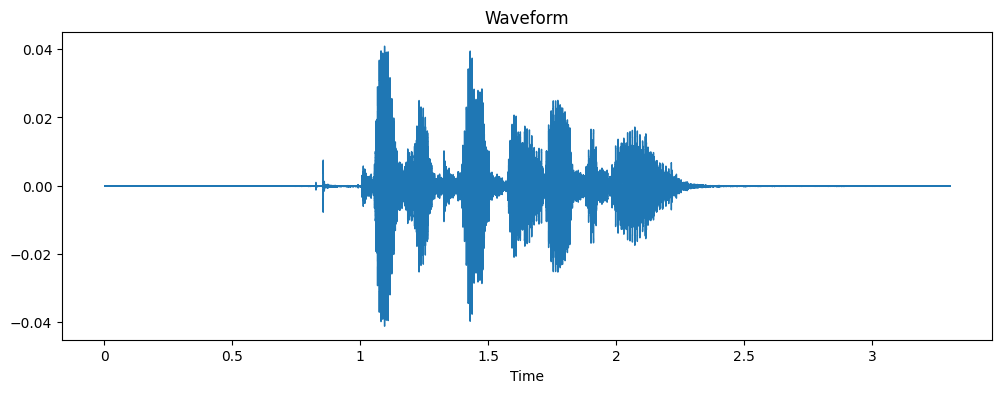

In [9]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

y, sr = librosa.load(r"D:\Bachelor Project Code\Audio_Speech_Actors_01-24\Actor_01\03-01-01-01-01-01-01.wav")

plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.show()

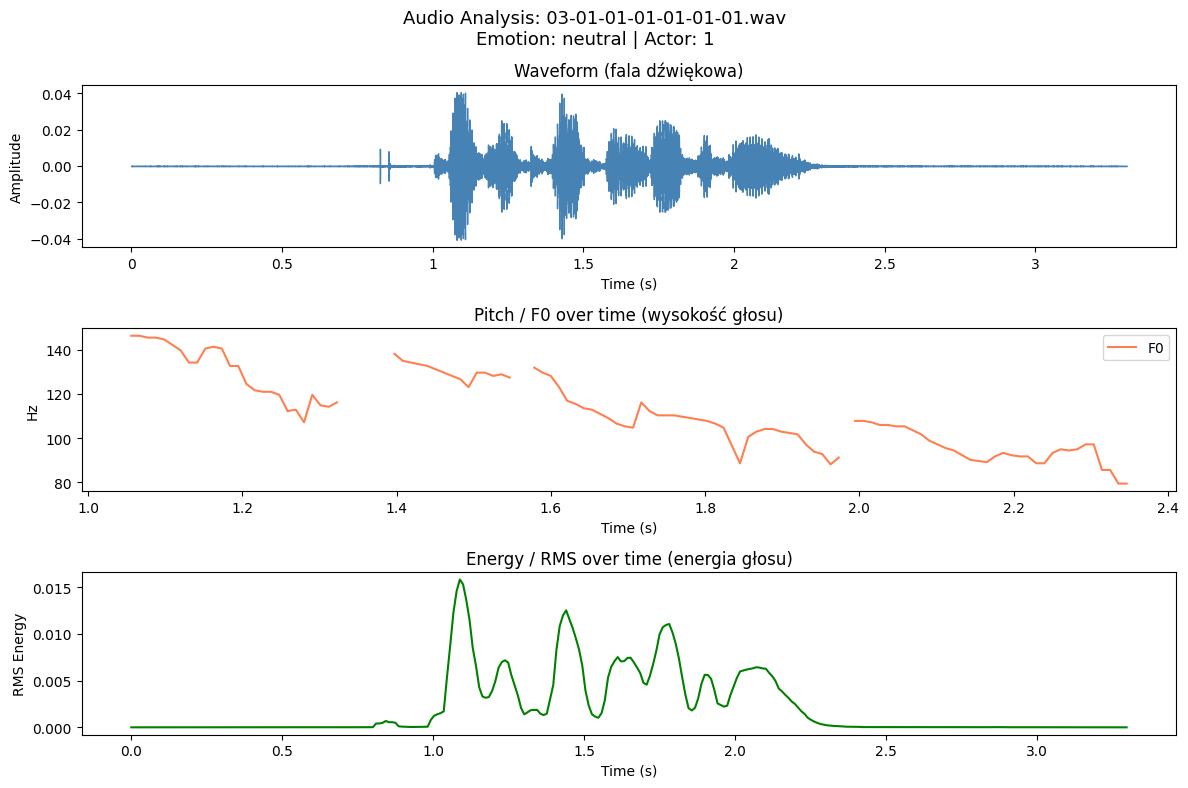

Plot saved at D:\Bachelor Project Code\Code\sample_analysis.png


In [10]:
# CELL 4 - Visualize one audio file
import matplotlib.pyplot as plt

y, sr = librosa.load(test_file, sr=None)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
fig.suptitle(f"Audio Analysis: {df['filename'].iloc[0]}\nEmotion: {df['emotion'].iloc[0]} | Actor: {df['actor_id'].iloc[0]}", 
             fontsize=13)

# Plot 1: Waveform (fala dźwiękowa)
axes[0].set_title("Waveform (fala dźwiękowa)")
librosa.display.waveshow(y, sr=sr, ax=axes[0], color='steelblue')
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("Amplitude")

# Plot 2: Pitch over time
f0, voiced_flag, _ = librosa.pyin(y, fmin=50, fmax=500, sr=sr)
times = librosa.times_like(f0, sr=sr)
axes[1].set_title("Pitch / F0 over time (wysokość głosu)")
axes[1].plot(times, f0, color='coral', linewidth=1.5, label='F0')
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Hz")
axes[1].legend()

# Plot 3: Energy over time
rms = librosa.feature.rms(y=y)[0]
rms_times = librosa.times_like(rms, sr=sr)
axes[2].set_title("Energy / RMS over time (energia głosu)")
axes[2].plot(rms_times, rms, color='green', linewidth=1.5)
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("RMS Energy")

plt.tight_layout()
plt.savefig(r"D:\Bachelor Project Code\Code\sample_analysis.png", dpi=150)
plt.show()
print("Plot saved at D:\\Bachelor Project Code\\Code\\sample_analysis.png")

Jitter i Shimmer — to są cechy jakości głosu. <br>
Jitter = nieregularność w częstotliwości między kolejnymi cyklami głosowymi. <br>
Shimmer = nieregularność amplitudy. 

<br>Wysoki jitter/shimmer = drżący, niestabilny głos (fearful, sad)

Cechy paralingwistyczne — pełna mapa<br>
obecny kod to dobry start, ale brakuje Ci kilku kluczowych grup. Oto kompletna lista oparta bezpośrednio na standardach z Twojej literatury (Schuller et al. 2009 / Interspeech Challenge, Juslin & Laukka 2003, Banse & Scherer 1996, Chan & Kuang 2024).
Podzielę je na 4 grupy według znaczenia dla Twoich hipotez:

GRUPA 0 — Pitch/F0 Based
```python
'pitch_mean'          # już 
'pitch_std'           # już 
'pitch_range'         # MAX - MICechy paralingwistyczne — pełna mapa
```

GRUPA 1 — Pitch/F0 (częściowo, rozszerz)
Fundament H1. Juslin & Laukka (2003) i Pell et al. (2009) wskazują F0 jako najsilniejszy dyskryminator emocji.
```python
'pitch_mean'          # już 
'pitch_std'           # już 
'pitch_range'         # MAX - MIN — kluczowe dla H1, TTS spłaszcza range
'pitch_max'           # wartość szczytowa
'pitch_min'
'voiced_fraction'     # % ramek z wykrytym pitchem — miara "phonation"
```
---
GRUPA 2 — Voice Quality (BRAK — priorytet)
To jest core H1. Früehholz & Trost (2023) i Banse & Scherer (1996) wprost wymieniają HNR, jitter i shimmer jako kluczowe dla emocji. TTS typowo ma zbyt regularny HNR i brak perturbacji.
```python
# HNR — Harmonics-to-Noise Ratio
# stosunek harmonicznej do szumowej części sygnału
# sadness → niski HNR, anger → wysoki HNR z perturbacjami
'hnr_mean'

# Jitter — perturbacje pitch (cycle-to-cycle F0 variation)
# strach i gniew → wysoki jitter
'jitter_local'        # średnia lokalna perturbacja F0
'jitter_ppq5'         # 5-punktowy smoothed jitter

# Shimmer — perturbacje amplitudy (cycle-to-cycle amplitude variation)
# silne emocje → wyższy shimmer
'shimmer_local'       # lokalna perturbacja amplitudy
'shimmer_apq5'        # 5-punktowy smoothed shimmer

⚠️ Uwaga techniczna: librosa nie ma natywnego HNR/jitter/shimmer. Użyj parselmouth (Python binding dla Praat) — to jest standard w tej dziedzinie:
import parselmouth
from parselmouth.praat import call

snd = parselmouth.Sound(audio_path)
# HNR
harmonicity = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
hnr = call(harmonicity, "Get mean", 0, 0)
# Jitter
point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)
jitter_local = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
# Shimmer
shimmer_local = call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
```
---
GRUPA 3 — Temporal/Rhythmic features (BRAK — priorytet)
Chan & Kuang (2024) pokazują, że pausing errors są największym deficytem TTS. Schuller et al. (2009) włącza speech rate jako standard.
```python
'speech_rate'         # sylaby lub ramki voiced / total duration
'pause_count'         # liczba pauz (segmentów ciszy > próg)
'pause_rate'          # pause_count / duration
'pause_mean_dur'      # średni czas trwania pauzy
'pause_total_dur'     # łączny czas ciszy
'voiced_duration'     # łączny czas fonacji
Implementacja przez librosa:
python# Detekcja pauz przez energy threshold
intervals = librosa.effects.split(y, top_db=30)
pause_durations = []
for i in range(1, len(intervals)):
    pause_dur = (intervals[i][0] - intervals[i-1][1]) / sr
    if pause_dur > 0.05:  # próg 50ms
        pause_durations.append(pause_dur)
```
---
GRUPA 4 — Spectral features (BRAK — standard w SER)
Schuller/Interspeech 2009 challenge definiuje MFCC 1-12 + ZCR + spektralne jako minimalny feature set dla wiarygodnej analizy. Bez nich nie możesz porównać wyników z literaturą.
```python
# MFCC — mel-frequency cepstral coefficients
# reprezentacja timbru/barwy głosu
# kluczowe dla voice quality differences human vs TTS
'mfcc_1_mean' ... 'mfcc_13_mean'     # 13 współczynników
'mfcc_1_std'  ... 'mfcc_13_std'      # ich wariancja

# Spectral centroid — "jasność" głosu
# anger/fear → wyższy centroid
'spectral_centroid_mean'
'spectral_centroid_std'

# Spectral rolloff — dystrybucja energii w spektrum
'spectral_rolloff_mean'

# High-frequency energy (HFE) — proporcja energii powyżej 1kHz
# Banse & Scherer (1996): kluczowy dla odróżnienia emocji
'hfe_ratio'           # energy(>1000Hz) / energy(total)
```

In [11]:
# CELL 5 - Complete feature extraction function
import parselmouth
from parselmouth.praat import call

def extract_features(filepath):
    # Load audio
    y, sr = librosa.load(filepath, sr=None)
    
    # === PITCH ===
    f0, voiced_flag, _ = librosa.pyin(y, fmin=50, fmax=500, sr=sr)
    f0_clean = f0[voiced_flag]
    pitch_mean = np.nanmean(f0_clean) if len(f0_clean) > 0 else 0
    pitch_std = np.nanstd(f0_clean) if len(f0_clean) > 0 else 0
    pitch_max = np.nanmax(f0_clean) if len(f0_clean) > 0 else 0
    pitch_min = np.nanmin(f0_clean) if len(f0_clean) > 0 else 0
    pitch_range = pitch_max - pitch_min
    voiced_fraction = np.sum(voiced_flag) / len(voiced_flag)

    # === ENERGY ===
    rms = librosa.feature.rms(y=y)[0]
    energy_mean = np.mean(rms)
    energy_std = np.std(rms)
    energy_range = np.max(rms) - np.min(rms)

    # === TEMPORAL / PAUSES ===
    duration = librosa.get_duration(y=y, sr=sr)
    intervals = librosa.effects.split(y, top_db=30)
    voiced_duration = np.sum([(e - s) for s, e in intervals]) / sr
    speech_rate = voiced_duration / duration if duration > 0 else 0

    pause_durations = []
    for i in range(1, len(intervals)):
        pause_dur = (intervals[i][0] - intervals[i-1][1]) / sr
        if pause_dur > 0.05:
            pause_durations.append(pause_dur)
    pause_count = len(pause_durations)
    pause_rate = pause_count / duration if duration > 0 else 0
    pause_mean_dur = np.mean(pause_durations) if pause_durations else 0

    # === SPECTRAL ===
    zcr_mean = np.mean(librosa.feature.zero_crossing_rate(y)[0])
    sc = librosa.feature.spectral_centroid(y=y, sr=sr)[0]
    spectral_centroid_mean = np.mean(sc)
    spectral_centroid_std = np.std(sc)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)[0]
    spectral_rolloff_mean = np.mean(rolloff)

    # High frequency energy ratio
    fft = np.abs(np.fft.rfft(y))
    freqs = np.fft.rfftfreq(len(y), 1/sr)
    hfe_ratio = np.sum(fft[freqs > 1000]**2) / (np.sum(fft**2) + 1e-10)

    # === MFCC ===
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc_means = np.mean(mfccs, axis=1)
    mfcc_stds = np.std(mfccs, axis=1)

    # === VOICE QUALITY (parselmouth/Praat) ===
    try:
        snd = parselmouth.Sound(filepath)
        harmonicity = call(snd, "To Harmonicity (cc)", 0.01, 75, 0.1, 1.0)
        hnr_mean = call(harmonicity, "Get mean", 0, 0)
        point_process = call(snd, "To PointProcess (periodic, cc)", 75, 500)
        jitter_local = call(point_process, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
        shimmer_local = call([snd, point_process], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    except:
        hnr_mean, jitter_local, shimmer_local = 0, 0, 0

    # === ASSEMBLE ===
    features = {
        'pitch_mean': pitch_mean,
        'pitch_std': pitch_std,
        'pitch_range': pitch_range,
        'pitch_max': pitch_max,
        'pitch_min': pitch_min,
        'voiced_fraction': voiced_fraction,
        'energy_mean': energy_mean,
        'energy_std': energy_std,
        'energy_range': energy_range,
        'duration': duration,
        'speech_rate': speech_rate,
        'pause_count': pause_count,
        'pause_rate': pause_rate,
        'pause_mean_dur': pause_mean_dur,
        'voiced_duration': voiced_duration,
        'zcr_mean': zcr_mean,
        'spectral_centroid_mean': spectral_centroid_mean,
        'spectral_centroid_std': spectral_centroid_std,
        'spectral_rolloff_mean': spectral_rolloff_mean,
        'hfe_ratio': hfe_ratio,
        'hnr_mean': hnr_mean,
        'jitter_local': jitter_local,
        'shimmer_local': shimmer_local,
        **{f'mfcc_{i+1}_mean': mfcc_means[i] for i in range(13)},
        **{f'mfcc_{i+1}_std': mfcc_stds[i] for i in range(13)},
    }
    return features

# Test on one file
test_features = extract_features(df['filepath'].iloc[0])
print(f"Features extracted: {len(test_features)}")
print(f"\nVoice quality:")
print(f"  HNR: {test_features['hnr_mean']:.2f} dB")
print(f"  Jitter: {test_features['jitter_local']:.4f}")
print(f"  Shimmer: {test_features['shimmer_local']:.4f}")
print(f"\nTemporal:")
print(f"  Speech rate: {test_features['speech_rate']:.2f}")
print(f"  Pause count: {test_features['pause_count']}")

Features extracted: 49

Voice quality:
  HNR: 7.49 dB
  Jitter: 0.0419
  Shimmer: 0.1378

Temporal:
  Speech rate: 0.40
  Pause count: 1


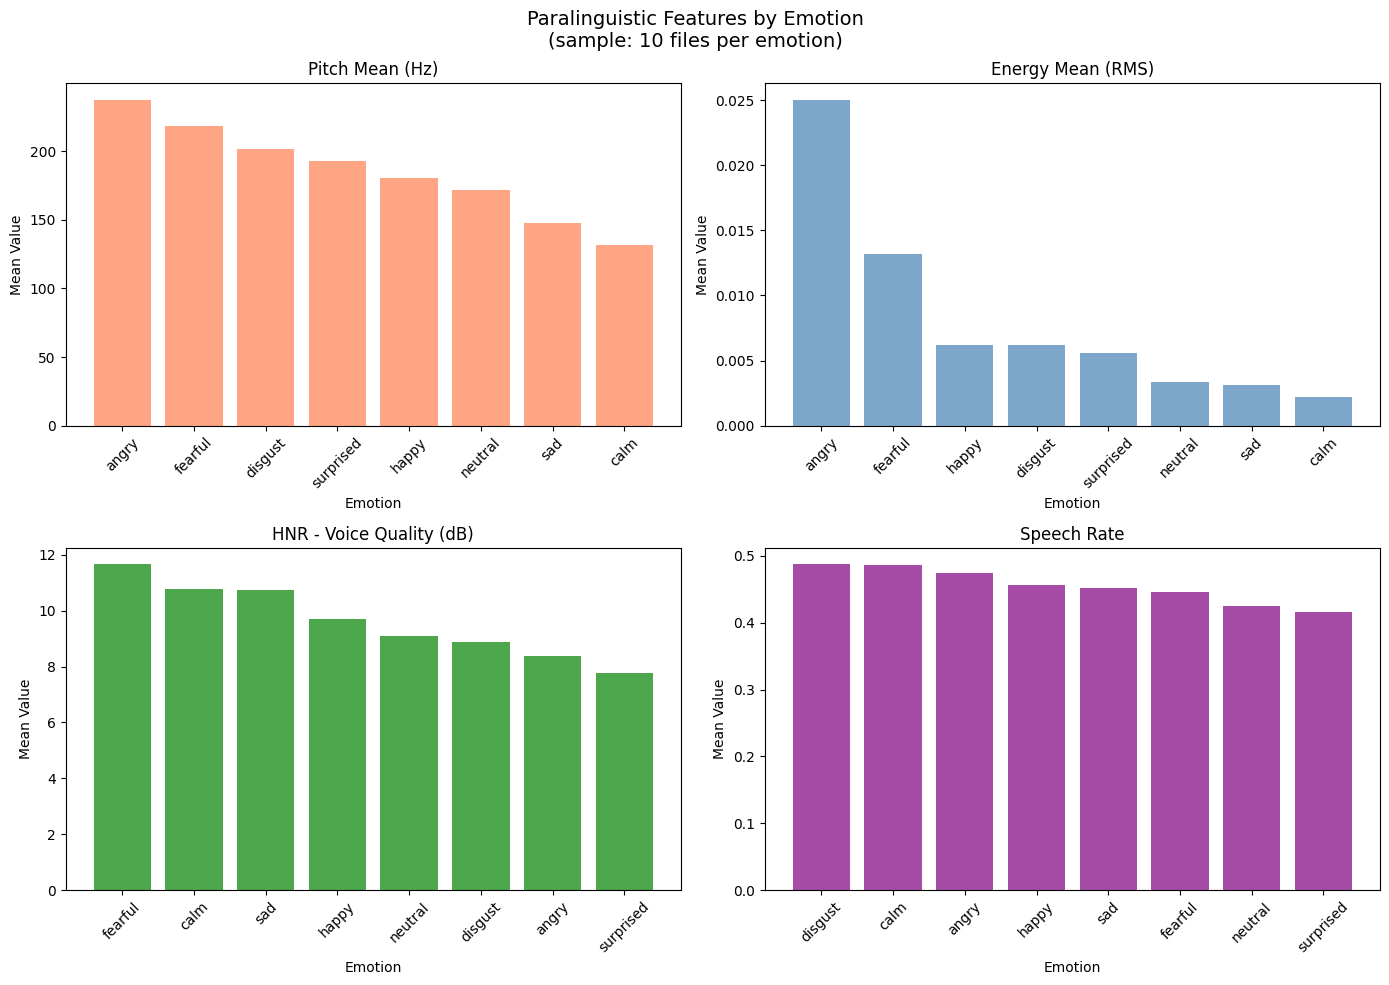

✓ Preview plot saved


In [17]:
# CELL 6 - Preview: extract features from 10 files per emotion
import matplotlib.pyplot as plt
import seaborn as sns

sample_results = []

for emotion in df['emotion'].unique():
    # 10 plików z każdej emocji
    sample = df[df['emotion'] == emotion].head(10)
    for idx, row in sample.iterrows():
        features = extract_features(row['filepath'])
        features['emotion'] = row['emotion']
        sample_results.append(features)

df_sample = pd.DataFrame(sample_results)

# Plot: 4 kluczowe cechy według emocji
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Paralinguistic Features by Emotion\n(sample: 10 files per emotion)", 
             fontsize=14)

features_to_plot = [
    ('pitch_mean', 'Pitch Mean (Hz)', 'coral'),
    ('energy_mean', 'Energy Mean (RMS)', 'steelblue'),
    ('hnr_mean', 'HNR - Voice Quality (dB)', 'green'),
    ('speech_rate', 'Speech Rate', 'purple'),
]

for ax, (feature, title, color) in zip(axes.flat, features_to_plot):
    emotion_means = df_sample.groupby('emotion')[feature].mean().sort_values(ascending=False)
    bars = ax.bar(emotion_means.index, emotion_means.values, color=color, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Emotion")
    ax.set_ylabel("Mean Value")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(r"D:\Bachelor Project Code\Code\emotion_preview.png", dpi=150)
plt.show()
print("✓ Preview plot saved")

In [19]:
# CELL 7 - Extract features from ALL files
from tqdm import tqdm

# pip install tqdm first if needed
results = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Extracting features"):
    features = extract_features(row['filepath'])
    features['filename'] = row['filename']
    features['emotion'] = row['emotion']
    features['intensity'] = row['intensity']
    features['actor_id'] = row['actor_id']
    features['gender'] = row['gender']
    results.append(features)

df_features = pd.DataFrame(results)

# Save to CSV
output_path = r"D:\Bachelor Project Code\Code\ravdess_features.csv"
df_features.to_csv(output_path, index=False)

print(f"✓ Done! Shape: {df_features.shape}")
print(f"✓ Saved to: {output_path}")

Extracting features: 100%|██████████| 1440/1440 [31:02<00:00,  1.29s/it]


PermissionError: [Errno 13] Permission denied: 'D:\\Bachelor Project Code\\Code\\ravdess_features.csv'

## Spike Testy
files:
ELv3_adam_happy_normal_kids_g1.mp3 <br>
ELv3_adam_happy_normal_kids_g2.mp3 <br>
ELv3_adam_sad_normal_kids_g1.mp3 <br>
ELv3_adam_sad_normal_kids_g2.mp3 <br>
ELv3_adam_angry_normal_kids_g1.mp3 <br>
ELv3_adam_angry_normal_kids_g2.mp3 <br>


AI-generated samples were initially produced in MP3 
format (44.1 kHz) due to platform export constraints, 
then losslessly converted to WAV using ffmpeg prior 
to feature extraction to ensure format consistency 
with RAVDESS source files.



In [13]:
# CELL - Convert MP3 to WAV (SpikeTest)
import subprocess
import os

INPUT_FOLDER = r"D:\Bachelor Project Code\ElevenLabs_Speech_Voices\SpikeTest"
OUTPUT_FOLDER = os.path.join(INPUT_FOLDER, "wav")
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

mp3_files = [f for f in os.listdir(INPUT_FOLDER) if f.endswith('.mp3')]
print(f"Found {len(mp3_files)} MP3 files")

for mp3_file in mp3_files:
    input_path = os.path.join(INPUT_FOLDER, mp3_file)
    output_name = mp3_file.replace('.mp3', '.wav')
    output_path = os.path.join(OUTPUT_FOLDER, output_name)
    
    # ffmpeg: konwersja do WAV 48kHz 16bit (identycznie jak RAVDESS)
    cmd = [
        'ffmpeg', '-i', input_path,
        '-ar', '48000',      # sample rate = 48kHz jak RAVDESS
        '-acodec', 'pcm_s16le',  # 16bit PCM
        '-ac', '1',          # mono
        output_path,
        '-y'                 # overwrite if exists
    ]
    
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    if result.returncode == 0:
        print(f"✓ {mp3_file} → {output_name}")
    else:
        print(f"✗ ERROR: {mp3_file}")
        print(result.stderr[-200:])

print(f"\nDone. WAV files saved to: {OUTPUT_FOLDER}")

Found 6 MP3 files
✓ ELv3_adam_angry_normal_kids_g1.mp3 → ELv3_adam_angry_normal_kids_g1.wav
✓ ELv3_adam_angry_normal_kids_g2.mp3 → ELv3_adam_angry_normal_kids_g2.wav
✓ ELv3_adam_happy_normal_kids_g1.mp3 → ELv3_adam_happy_normal_kids_g1.wav
✓ ELv3_adam_happy_normal_kids_g2.mp3 → ELv3_adam_happy_normal_kids_g2.wav
✓ ELv3_adam_sad_normal_kids_g1.mp3 → ELv3_adam_sad_normal_kids_g1.wav
✓ ELv3_adam_sad_normal_kids_g2.mp3 → ELv3_adam_sad_normal_kids_g2.wav

Done. WAV files saved to: D:\Bachelor Project Code\ElevenLabs_Speech_Voices\SpikeTest\wav


In [14]:
# CELL - SpikeTest: Extract features from ElevenLabs WAV files
import parselmouth
from parselmouth.praat import call

WAV_FOLDER = r"D:\Bachelor Project Code\ElevenLabs_Speech_Voices\SpikeTest\wav"

# Parse filename metadata
def parse_el_filename(filename):
    parts = filename.replace('.wav', '').split('_')
    # ELv3_adam_happy_normal_kids_g1
    return {
        'model': parts[0],
        'voice': parts[1],
        'emotion': parts[2],
        'intensity': parts[3],
        'statement': parts[4],
        'generation': parts[5],
        'voice_type': 'AI'
    }

# Extract features from all 6 files
el_results = []

for filename in sorted(os.listdir(WAV_FOLDER)):
    if not filename.endswith('.wav'):
        continue
    
    filepath = os.path.join(WAV_FOLDER, filename)
    features = extract_features(filepath)
    metadata = parse_el_filename(filename)
    
    features['filename'] = filename
    features.update(metadata)
    el_results.append(features)
    print(f"✓ {filename}")

df_el = pd.DataFrame(el_results)
print(f"\nShape: {df_el.shape}")
print(f"Emotions: {df_el['emotion'].tolist()}")

✓ ELv3_adam_angry_normal_kids_g1.wav
✓ ELv3_adam_angry_normal_kids_g2.wav
✓ ELv3_adam_happy_normal_kids_g1.wav
✓ ELv3_adam_happy_normal_kids_g2.wav
✓ ELv3_adam_sad_normal_kids_g1.wav
✓ ELv3_adam_sad_normal_kids_g2.wav

Shape: (6, 57)
Emotions: ['angry', 'angry', 'happy', 'happy', 'sad', 'sad']


## Porownanie MP3 z WAV czy sa rzeczywiscie duze roznice miedzy WAV a MP3 i czy na MP3 jest to tak duzo stratne <br>

### czy jest oplacalne robic konwersje na WAV?

In [15]:
# CELL - Compare MP3 vs WAV features
MP3_FOLDER = r"D:\Bachelor Project Code\ElevenLabs_Speech_Voices\SpikeTest"

el_mp3_results = []

for filename in sorted(os.listdir(MP3_FOLDER)):
    if not filename.endswith('.mp3'):
        continue
    
    filepath = os.path.join(MP3_FOLDER, filename)
    features = extract_features(filepath)
    metadata = parse_el_filename(filename.replace('.mp3', '.wav'))
    features['filename'] = filename
    features['format'] = 'MP3'
    features.update(metadata)
    el_mp3_results.append(features)

df_mp3 = pd.DataFrame(el_mp3_results)

# Compare key features MP3 vs WAV
compare_features = ['hnr_mean', 'shimmer_local', 'jitter_local', 
                    'hfe_ratio', 'spectral_rolloff_mean', 'mfcc_10_mean']

print("Feature comparison MP3 vs WAV (means across 6 files):\n")
print(f"{'Feature':<25} {'MP3':>10} {'WAV':>10} {'Diff%':>10}")
print("-" * 55)

for feat in compare_features:
    mp3_val = df_mp3[feat].mean()
    wav_val = df_el[feat].mean()
    diff_pct = ((wav_val - mp3_val) / (abs(mp3_val) + 1e-10)) * 100
    print(f"{feat:<25} {mp3_val:>10.4f} {wav_val:>10.4f} {diff_pct:>9.1f}%")

Feature comparison MP3 vs WAV (means across 6 files):

Feature                          MP3        WAV      Diff%
-------------------------------------------------------
hnr_mean                      5.2502     5.2269      -0.4%
shimmer_local                 0.1485     0.1593       7.3%
jitter_local                  0.0398     0.0402       1.1%
hfe_ratio                     0.2041     0.2041       0.0%
spectral_rolloff_mean      5775.5632  5730.0814      -0.8%
mfcc_10_mean                  5.1813     2.5627     -50.5%


In [20]:
#Sprawdzamy czy df_features jest w pamieci i poprawnie wczytany
print(df_features.shape)
print(df_features['emotion'].value_counts())

(1440, 54)
emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


In [ ]:
#zapisywanie do CSV v2 jako backup
    #plik jest ten sam co v1 - zapis na v2 bo plik v1 byl otwarty w excelu i nie mozna bylo nadpisac
output_path = r"D:\Bachelor Project Code\Code\ravdess_features_v2.csv"
df_features.to_csv(output_path, index=False)
print(f"✓ Saved: {output_path}")

✓ Saved: D:\Bachelor Project Code\Code\ravdess_features_v2.csv


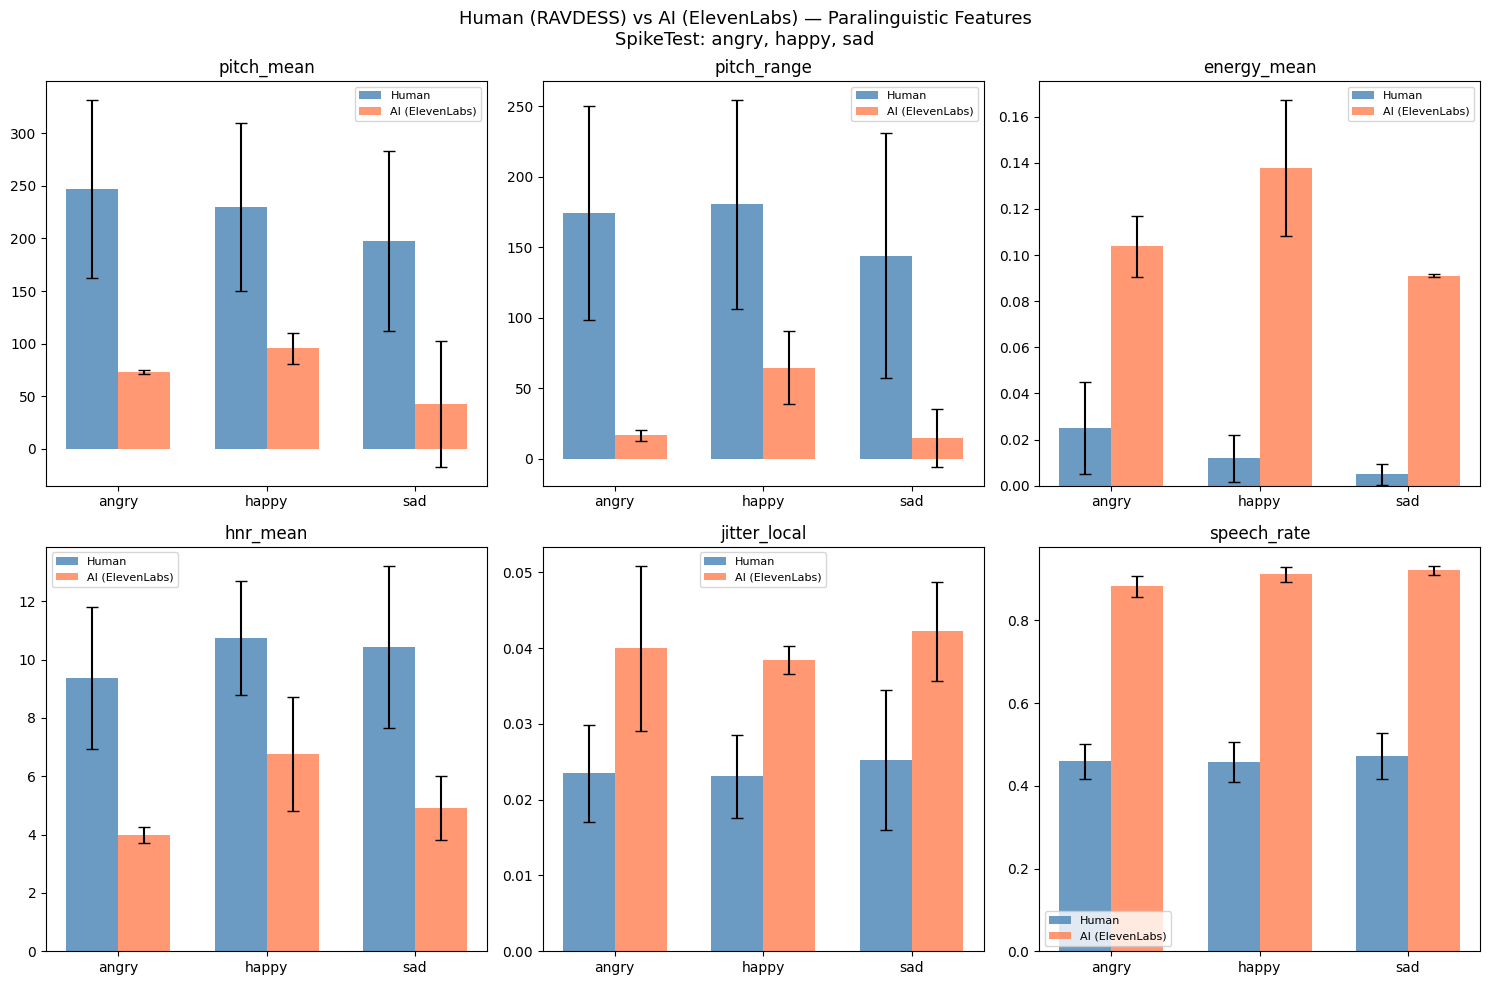

✓ Plot saved


In [23]:
# CELL - Human vs AI comparison (SpikeTest)
import matplotlib.pyplot as plt
import numpy as np

# Prepare RAVDESS subset - only emotions matching ElevenLabs
emotions_to_compare = ['angry', 'happy', 'sad']
df_human_subset = df_features[df_features['emotion'].isin(emotions_to_compare)].copy()
df_human_subset['voice_type'] = 'Human'
df_el['voice_type'] = 'AI'

# Key features to compare
key_features = ['pitch_mean', 'pitch_range', 'energy_mean', 
                'hnr_mean', 'jitter_local', 'speech_rate']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Human (RAVDESS) vs AI (ElevenLabs) — Paralinguistic Features\nSpikeTest: angry, happy, sad", 
             fontsize=13)

colors_human = {'angry': '#d62728', 'happy': '#2ca02c', 'sad': '#1f77b4'}
colors_ai = {'angry': '#ff9896', 'happy': '#98df8a', 'sad': '#aec7e8'}

for ax, feature in zip(axes.flat, key_features):
    x = np.arange(len(emotions_to_compare))
    width = 0.35
    
    human_means = [df_human_subset[df_human_subset['emotion']==e][feature].mean() 
                   for e in emotions_to_compare]
    human_stds = [df_human_subset[df_human_subset['emotion']==e][feature].std() 
                  for e in emotions_to_compare]
    
    ai_means = [df_el[df_el['emotion']==e][feature].mean() 
                for e in emotions_to_compare]
    ai_stds = [df_el[df_el['emotion']==e][feature].std() 
               for e in emotions_to_compare]
    
    bars1 = ax.bar(x - width/2, human_means, width, 
                   yerr=human_stds, label='Human', 
                   color='steelblue', alpha=0.8, capsize=4)
    bars2 = ax.bar(x + width/2, ai_means, width,
                   yerr=ai_stds, label='AI (ElevenLabs)',
                   color='coral', alpha=0.8, capsize=4)
    
    ax.set_title(feature)
    ax.set_xticks(x)
    ax.set_xticklabels(emotions_to_compare)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(r"D:\Bachelor Project Code\Code\human_vs_ai_spiketest.png", dpi=150)
plt.show()
print("✓ Plot saved")